In [1]:
import pandas as pd
import numpy as np
import numpy.random as rand
import scipy.stats
import matplotlib as mpl
import matplotlib.pyplot as plt

/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Read in expression table
rna = pd.read_table('/home/eholc/HW8/GD660.TrQuantRPKM.txt')
rna

,TargetID,Gene_Symbol,Chr,Coord,HG00096.1.M_111124_6,HG00097.7.M_120219_2,HG00099.1.M_120209_6,HG00099.5.M_120131_3,HG00100.2.M_111215_8,HG00101.1.M_111124_4,...,NA20810.2.M_111215_7,NA20811.1.M_111124_5,NA20812.2.M_111216_6,NA20813.5.M_120131_1,NA20814.2.M_111215_6,NA20815.5.M_120131_5,NA20816.3.M_120202_7,NA20819.3.M_120202_2,NA20826.1.M_111124_1,NA20828.2.M_111216_8
0,ENST00000454411.1,ENSG00000237851.1,6,143109260,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,ENST00000425977.1,ENSG00000225538.1,11,55850277,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.03876,0.00000
2,ENST00000417072.1,ENSG00000212855.5,Y,9578193,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
3,ENST00000552753.1,ENSG00000257527.1,16,18505708,0.70561,0.66697,0.64004,0.26195,0.34695,1.49208,...,0.87085,0.94950,0.95837,0.51002,0.29422,0.22960,0.58671,0.27674,0.53630,0.17139
4,ENST00000470114.1,ENSG00000243765.1,15,58442766,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183081,ENST00000569773.1,ENSG00000006007.7,16,19533467,0.00000,0.25167,0.00000,0.29288,0.00000,0.00000,...,0.00000,0.00000,19.04685,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
183082,ENST00000390751.1,ENSG00000212040.1,14,101498324,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
183083,ENST00000559497.1,ENSG00000259738.1,15,59157205,0.00000,0.13191,0.00000,0.00000,0.15789,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
183084,ENST00000416709.1,ENSG00000230711.2,6,168690030,0.20363,0.18754,0.18268,0.27913,0.28883,0.20242,...,0.26582,0.19322,0.28367,0.30192,0.20901,0.15291,0.27677,0.59387,0.22323,0.30439


In [3]:
# 1. Determine which transcript has the largest range in RPKM values across all samples.
ranges = {}                                 # Create dictionary to store ranges for each row
rpkm_columns = rna.iloc[:, 4:]              # Subset only the columns with expression data

for index, row in rpkm_columns.iterrows():  # Loop through each row
    max_value = row.max()                   # Find the max of each row
    min_value = row.min()                   # Find the min of each row
    range_value = max_value - min_value     # Calculate range of each row
    
    ranges[index] = range_value             # Add range value to row index
    
max_range_index = max(ranges, key=ranges.get)    # Find index with the max range
max_range_value = max(ranges.values())           # Find max range value

my_gene = rna.loc[max_range_index]               # Find gene with the max range index

In [5]:
my_gene

TargetID                ENST00000419932.1
Gene_Symbol             ENSG00000226958.1
Chr                                     X
Coord                           108297792
HG00096.1.M_111124_6           2338.87768
                              ...        
NA20815.5.M_120131_5           2809.14257
NA20816.3.M_120202_7           1655.52294
NA20819.3.M_120202_2            830.08642
NA20826.1.M_111124_1           3222.13354
NA20828.2.M_111216_8             820.5487
Name: 4555, Length: 664, dtype: object

In [6]:
my_gene["Gene_Symbol"]

'ENSG00000226958.1'

In [7]:
max_range_index

4555

In [8]:
max_range_value

75909.87262

In [13]:
# Using the file gencode.v12.annotation.gtf, determine the name of the corresponding gene.
# Read in annotation file

from gtfparse import read_gtf
anno = read_gtf('/home/eholc/HW8/gencode.v12.annotation.gtf')

# Change anno file from Polars DataFrame to a pandas DataFrame
anno = anno.to_pandas()
anno

INFO:root:Extracted GTF attributes: ['gene_id', 'transcript_id', 'gene_type', 'gene_status', 'gene_name', 'transcript_type', 'transcript_status', 'transcript_name', 'level', 'havana_gene', 'havana_transcript', 'ont', 'tag', 'ccdsid']


,seqname,source,feature,start,end,score,strand,frame,gene_id,transcript_id,...,gene_name,transcript_type,transcript_status,transcript_name,level,havana_gene,havana_transcript,ont,tag,ccdsid
0,chr1,HAVANA,gene,11869,14412,NaN,+,0,ENSG00000223972.4,ENSG00000223972.4,...,DDX11L1,pseudogene,KNOWN,DDX11L1,2,OTTHUMG00000000961.2,,,,
1,chr1,HAVANA,transcript,11869,14409,NaN,+,0,ENSG00000223972.4,ENST00000456328.2,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
2,chr1,HAVANA,exon,11869,12227,NaN,+,0,ENSG00000223972.4,ENST00000456328.2,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
3,chr1,HAVANA,exon,12613,12721,NaN,+,0,ENSG00000223972.4,ENST00000456328.2,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
4,chr1,HAVANA,exon,13221,14409,NaN,+,0,ENSG00000223972.4,ENST00000456328.2,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616292,chrM,ENSEMBL,transcript,15888,15953,NaN,+,0,ENSG00000210195.2,ENST00000387460.2,...,J01415.22,Mt_tRNA,NOVEL,J01415.22-201,3,,,,,
2616293,chrM,ENSEMBL,exon,15888,15953,NaN,+,0,ENSG00000210195.2,ENST00000387460.2,...,J01415.22,Mt_tRNA,NOVEL,J01415.22-201,3,,,,,
2616294,chrM,ENSEMBL,gene,15956,16023,NaN,-,0,ENSG00000210196.2,ENSG00000210196.2,...,J01415.23,Mt_tRNA,NOVEL,J01415.23,3,,,,,
2616295,chrM,ENSEMBL,transcript,15956,16023,NaN,-,0,ENSG00000210196.2,ENST00000387461.2,...,J01415.23,Mt_tRNA,NOVEL,J01415.23-201,3,,,,,


In [10]:
# Index anno dataframe by gene_id
anno = anno.set_index('gene_id')
anno

,seqname,source,feature,start,end,score,strand,frame,transcript_id,gene_type,...,gene_name,transcript_type,transcript_status,transcript_name,level,havana_gene,havana_transcript,ont,tag,ccdsid
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972.4,chr1,HAVANA,gene,11869,14412,NaN,+,0,ENSG00000223972.4,pseudogene,...,DDX11L1,pseudogene,KNOWN,DDX11L1,2,OTTHUMG00000000961.2,,,,
ENSG00000223972.4,chr1,HAVANA,transcript,11869,14409,NaN,+,0,ENST00000456328.2,pseudogene,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
ENSG00000223972.4,chr1,HAVANA,exon,11869,12227,NaN,+,0,ENST00000456328.2,pseudogene,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
ENSG00000223972.4,chr1,HAVANA,exon,12613,12721,NaN,+,0,ENST00000456328.2,pseudogene,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
ENSG00000223972.4,chr1,HAVANA,exon,13221,14409,NaN,+,0,ENST00000456328.2,pseudogene,...,DDX11L1,processed_transcript,KNOWN,DDX11L1-002,2,OTTHUMG00000000961.2,OTTHUMT00000362751.1,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000210195.2,chrM,ENSEMBL,transcript,15888,15953,NaN,+,0,ENST00000387460.2,Mt_tRNA,...,J01415.22,Mt_tRNA,NOVEL,J01415.22-201,3,,,,,
ENSG00000210195.2,chrM,ENSEMBL,exon,15888,15953,NaN,+,0,ENST00000387460.2,Mt_tRNA,...,J01415.22,Mt_tRNA,NOVEL,J01415.22-201,3,,,,,
ENSG00000210196.2,chrM,ENSEMBL,gene,15956,16023,NaN,-,0,ENSG00000210196.2,Mt_tRNA,...,J01415.23,Mt_tRNA,NOVEL,J01415.23,3,,,,,


In [11]:
# Select rows with our gene symbol
my_gene_symbol = anno.loc[my_gene["Gene_Symbol"]]
my_gene_symbol

,seqname,source,feature,start,end,score,strand,frame,transcript_id,gene_type,...,gene_name,transcript_type,transcript_status,transcript_name,level,havana_gene,havana_transcript,ont,tag,ccdsid
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000226958.1,chrX,HAVANA,gene,108297361,108297792,NaN,-,0,ENSG00000226958.1,pseudogene,...,RN28S1,pseudogene,KNOWN,RN28S1,2,OTTHUMG00000040033.1,,,,
ENSG00000226958.1,chrX,HAVANA,transcript,108297361,108297792,NaN,-,0,ENST00000419932.1,pseudogene,...,RN28S1,processed_pseudogene,KNOWN,RN28S1-001,2,OTTHUMG00000040033.1,OTTHUMT00000096568.1,PGO:0000004,,
ENSG00000226958.1,chrX,HAVANA,exon,108297361,108297792,NaN,-,0,ENST00000419932.1,pseudogene,...,RN28S1,processed_pseudogene,KNOWN,RN28S1-001,2,OTTHUMG00000040033.1,OTTHUMT00000096568.1,PGO:0000004,,


In [12]:
print(my_gene_symbol['gene_name'])

gene_id
ENSG00000226958.1    RN28S1
ENSG00000226958.1    RN28S1
ENSG00000226958.1    RN28S1
Name: gene_name, dtype: object


In [4]:
# 2. Next, randomly pick a sample from the 660 listed samples to work with.
sample = rna['HG00097.7.M_120219_2']     # I chose the second sample
sample

0         0.00000
1         0.00000
2         0.00000
3         0.66697
4         0.00000
           ...   
183081    0.25167
183082    0.00000
183083    0.13191
183084    0.18754
183085    0.07601
Name: HG00097.7.M_120219_2, Length: 183086, dtype: float64

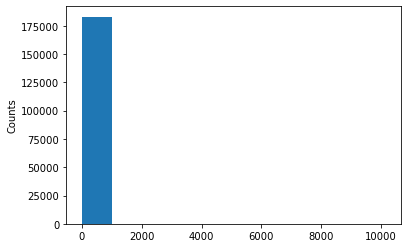

In [5]:
# 2.a Make a histogram of the RPKM counts for your sample in the Geuvadis data.
_ = plt.hist(sample, bins=10)
_ = plt.ylabel('Counts')

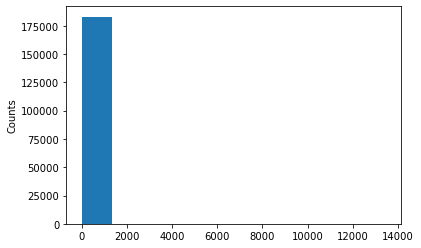

In [3]:
# 2.b Convert RPKM values to TPM, and make a histogram of the TPM values
    # rpkm = gene_reads / (gene_length_in_kb * total_reads)
    # tpm = (rpk / rpk_sum) * 10^6 (All values in sample sum to 1^6)

rpkm_columns = rna.iloc[:, 4:]                                     # Subset only the columns with rpkm expression data
rna_tpm_values = (rpkm_columns / rpkm_columns.sum()) * 1e6         # Calculate tpm values

original_columns = rna.iloc[:, :4]                                 # Original columns (not expression data)
rna_tpm = pd.concat([original_columns, rna_tpm_values], axis = 1)  # Combine original columns with new tpm columns (axis=1 means to combine columns)

_ = plt.hist(rna_tpm['HG00097.7.M_120219_2'], bins=10)
_ = plt.ylabel('Counts')

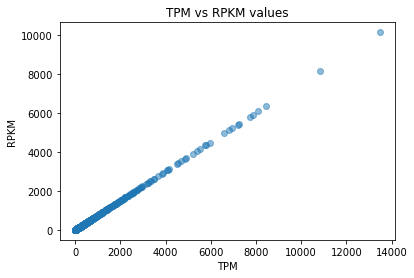

In [35]:
# 2.c Make a scatter plot of TPM vs RPKM values
_ = plt.scatter(rna_tpm['HG00097.7.M_120219_2'],rna['HG00097.7.M_120219_2'], alpha=0.5, label = 'TPM vs RPKM')
_ = plt.xlabel("TPM")
_ = plt.ylabel("RPKM")
_ = plt.title('TPM vs RPKM values')

In [4]:
# 3. Determine TPM values for your sample using kallisto.
# 3.a Using the file E-GEUV-1.sdrf.txt, determine the locations for the RNAseq fastq files associated with your sample.
url_table = pd.read_table('/home/eholc/HW8/E-GEUV-1.sdrf.txt')
url_table

,Source Name,Comment[ENA_SAMPLE],Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Characteristics[population],Comment[1000g Phase1 Genotypes],Protocol REF,Protocol REF.1,...,Protocol REF.3,Scan Name,Comment[SUBMITTED_FILE_NAME],Comment[ENA_RUN],Comment[FASTQ_URI],Protocol REF.4,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[population],Factor Value[laboratory]
0,HG00096,ERS185276,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00096.1.M_111124_6_1.fastq.gz,HG00096.1.M_111124_6_1.fastq.gz,ERR188040,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00096.1.M_111124_6.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,1
1,HG00096,ERS185276,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00096.1.M_111124_6_2.fastq.gz,HG00096.1.M_111124_6_2.fastq.gz,ERR188040,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00096.1.M_111124_6.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,1
2,HG00097,ERS185206,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00097.7.M_120219_2_1.fastq.gz,HG00097.7.M_120219_2_1.fastq.gz,ERR188231,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00097.7.M_120219_2.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,7
3,HG00097,ERS185206,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00097.7.M_120219_2_2.fastq.gz,HG00097.7.M_120219_2_2.fastq.gz,ERR188231,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00097.7.M_120219_2.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,7
4,HG00099,ERS185128,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00099.5.M_120131_3_1.fastq.gz,HG00099.5.M_120131_3_1.fastq.gz,ERR188428,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00099.5.M_120131_3.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,NA20819,ERS185339,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,TSI,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,NA20819.3.M_120202_2_2.fastq.gz,NA20819.3.M_120202_2_2.fastq.gz,ERR188424,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,NA20819.3.M_120202_2.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,TSI,3
920,NA20826,ERS185259,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,TSI,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,NA20826.1.M_111124_1_1.fastq.gz,NA20826.1.M_111124_1_1.fastq.gz,ERR188125,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,NA20826.1.M_111124_1.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,TSI,1
921,NA20826,ERS185259,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,TSI,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,NA20826.1.M_111124_1_2.fastq.gz,NA20826.1.M_111124_1_2.fastq.gz,ERR188125,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,NA20826.1.M_111124_1.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,TSI,1
922,NA20828,ERS185459,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,TSI,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,NA20828.2.M_111216_8_1.fastq.gz,NA20828.2.M_111216_8_1.fastq.gz,ERR188406,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,NA20828.2.M_111216_8.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,TSI,2


In [38]:
# Select row that contains 'HG00097.7.M_120219_2' in the column "Scan Name"
sample_url_table = url_table[url_table['Scan Name'].str.contains('HG00097.7.M_120219_2')]
sample_url_table

,Source Name,Comment[ENA_SAMPLE],Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Characteristics[population],Comment[1000g Phase1 Genotypes],Protocol REF,Protocol REF.1,...,Protocol REF.3,Scan Name,Comment[SUBMITTED_FILE_NAME],Comment[ENA_RUN],Comment[FASTQ_URI],Protocol REF.4,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[population],Factor Value[laboratory]
2,HG00097,ERS185206,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00097.7.M_120219_2_1.fastq.gz,HG00097.7.M_120219_2_1.fastq.gz,ERR188231,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00097.7.M_120219_2.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,7
3,HG00097,ERS185206,Homo sapiens,NCBI Taxonomy,9606,lymphoblastoid cell line,GBR,1,P-GEUV-1,P-GEUV-2,...,P-GEUV-6,HG00097.7.M_120219_2_2.fastq.gz,HG00097.7.M_120219_2_2.fastq.gz,ERR188231,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR1...,P-GEUV-7,HG00097.7.M_120219_2.bam,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,GBR,7


In [49]:
# Find url for R1
R1 = sample_url_table['Comment[FASTQ_URI]'].iloc[0]
R1

'ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR188231/ERR188231_1.fastq.gz'

In [50]:
# Find url for R2
R2 = sample_url_table['Comment[FASTQ_URI]'].iloc[1]
R2

'ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR188231/ERR188231_2.fastq.gz'

In [ ]:
# Then, download R1 and R2 to an appropriate directory on Great Lakes using the unix wget command (I did this in terminal)
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR188231/ERR188231_1.fastq.gz
wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR188/ERR188231/ERR188231_2.fastq.gz

In [ ]:
# Take a look at one of the files (in terminal)
zcat ERR1882321_1.fastq.gz  | head

# @ERR188231.1 HWI-962:71:D0PEYACXX:2:1101:1134:2168/1
# CTCGCTTCGCTTTTCCTCCGCAACCATGTCTGACAAACCCGATATGGCTGAGATCGAGAAATTCGATAAGTCGAA
# +
# CCCFFFFFHHHHHJJJJJJJIGFIIIJJJIJJFHIIIJJJJJJJJIJJJJHHHGHFFDBCEEEDDEEDBCCCDBB
# @ERR188231.2 HWI-962:71:D0PEYACXX:2:1101:1375:2152/1
# TCTNCAGTATTTAGACCATCAGATCTTGTGAAACCCACGTACTATCATGAGAACAGCCCAGGAAAGACGCACCTC
# +
# @C@#4ABDHHHHHIJJIIJJJJJIIHIJHHEIIJIIJJIGGIIIJJJFHBDGHHEGIHHE=ACHIGEHFFEFDEE
# @ERR188231.3 HWI-962:71:D0PEYACXX:2:1101:1309:2171/1
# ATTCCATTACTTGCTGCTTTTTTTTTTTTATTTGGAAAGTTTGCTTATAACTCTGATCAAGGCCCCATTTTCATC

In [23]:
# 3.b Estimate gene abundance for your sample using kallisto. The commands can be executed interactively as we have done in class.
# An index file of the transcriptome, defined by gencode v12, has already been generated in the file:
    # /scratch/humgen551w25_class_root/humgen551w25_class/shared_data/HW7/gencode_v12.index

module load Bioinformatics
module load kallisto/0.46.0

kallisto quant --plaintext \
-i /home/eholc/HW8/gencode_v12.index \
-o sample-HG00097 \
ERR188231_1.fastq.gz ERR188231_2.fastq.gz

# This utilizes the v12 gencode transcript set as in the Geuvadis paper. 
# The resulting output will include TPM estimates for each transcript target in the GTF file.

In [5]:
# 3.c. Read in the TPM estimate and make a scatter plot of the kallisto vs Geuvadis estimates for your chosen sample. 
    # Be aware that the order of transcript names may not be the same between these two data sets. 
    # You will have to construct properly ordered lists of equal size for plotting.

kallisto_sample = pd.read_table('/home/eholc/HW8/sample-HG00097/abundance.tsv')

kallisto_sample = kallisto_sample.rename(columns={'target_id': 'TargetID'})
kallisto_sample

,TargetID,length,eff_length,est_counts,tpm
0,ENST00000343114.3,2846,2667.550,0.00000,0.000000
1,ENST00000411191.1,88,30.400,0.00000,0.000000
2,ENST00000388767.3,2397,2218.550,2.17855,0.022076
3,ENST00000413975.1,382,205.355,0.00000,0.000000
4,ENST00000423705.1,938,759.635,0.00000,0.000000
...,...,...,...,...,...
183081,ENST00000491852.1,1015,836.554,0.00000,0.000000
183082,ENST00000536373.1,759,580.635,0.00000,0.000000
183083,ENST00000513806.1,432,254.382,30.17080,2.666420
183084,ENST00000548116.1,1913,1734.550,5.40794,0.070093


In [6]:
# Merge kallisto vs Geuvadis sample data to organize gene lists
original_columns = rna.iloc[:, :4]                                          # Original columns (not expression data)
geuvadis_column = rna['HG00097.7.M_120219_2']                               # Geuvadis sample expression data
geuvadis_sample = pd.concat([original_columns, geuvadis_column], axis = 1)  # Combine original columns with Geuvadis sample expression column (axis=1 means to combine columns)

merged_data = pd.merge(geuvadis_sample, kallisto_sample, on = 'TargetID')   # Merge geuvadis and kallisto sample data
merged_data

,TargetID,Gene_Symbol,Chr,Coord,HG00097.7.M_120219_2,length,eff_length,est_counts,tpm
0,ENST00000454411.1,ENSG00000237851.1,6,143109260,0.00000,444,266.2780,1.14454,0.096633
1,ENST00000425977.1,ENSG00000225538.1,11,55850277,0.00000,939,760.6350,0.00000,0.000000
2,ENST00000417072.1,ENSG00000212855.5,Y,9578193,0.00000,3168,2989.5500,0.00000,0.000000
3,ENST00000552753.1,ENSG00000257527.1,16,18505708,0.66697,543,364.7950,7.47929,0.460936
4,ENST00000470114.1,ENSG00000243765.1,15,58442766,0.00000,68,25.2308,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...
183081,ENST00000569773.1,ENSG00000006007.7,16,19533467,0.25167,739,560.6350,0.00000,0.000000
183082,ENST00000390751.1,ENSG00000212040.1,14,101498324,0.00000,78,30.1702,0.00000,0.000000
183083,ENST00000559497.1,ENSG00000259738.1,15,59157205,0.13191,298,125.8640,2.00000,0.357237
183084,ENST00000416709.1,ENSG00000230711.2,6,168690030,0.18754,2446,2267.5500,0.00000,0.000000


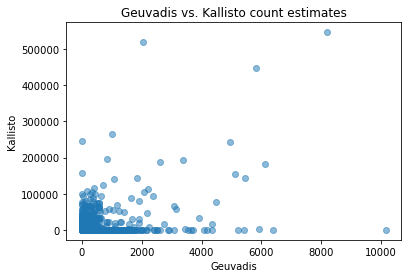

In [7]:
_ = plt.scatter(merged_data['HG00097.7.M_120219_2'], merged_data['est_counts'], alpha=0.5)
_ = plt.xlabel("Geuvadis")
_ = plt.ylabel("Kallisto")
_ = plt.title('Geuvadis vs. Kallisto count estimates')

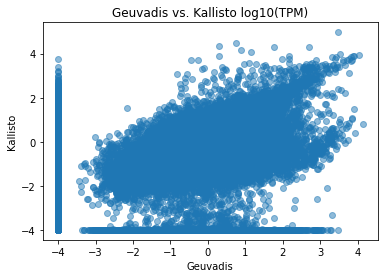

In [8]:
# 3.d. Construct a scatter plot of log10(TPM) values for the data sets. 
# Since log10(0) is not defined, you might consider adding a small value to each TPM value first.

# Merge kallisto vs Geuvadis TPM sample data to organize gene lists
original_columns = rna_tpm.iloc[:, :4]                                       # Original columns (not expression data)
geuvadis_column = rna_tpm['HG00097.7.M_120219_2']                            # Geuvadis sample expression data
geuvadis_sample = pd.concat([original_columns, geuvadis_column], axis = 1)   # Combine original columns with Geuvadis sample expression column (axis=1 means to combine columns)

merged_tpm_data = pd.merge(geuvadis_sample, kallisto_sample, on = 'TargetID')    # Merge geuvadis and kallisto sample data

# Convert TPM to log10(TPM)
geuvadis_log = np.log10((merged_tpm_data['HG00097.7.M_120219_2']) + 0.0001)
kallisto_log = np.log10((merged_tpm_data['tpm']) + 0.0001)


_ = plt.scatter(geuvadis_log, kallisto_log, alpha=0.5)
_ = plt.xlabel("Geuvadis")
_ = plt.ylabel("Kallisto")
_ = plt.title('Geuvadis vs. Kallisto log10(TPM)')

In [9]:
# 3.e. Calculate the Pearson and Spearman correlation between the Geuvadis and kallisto estimates for your sample. 
# Write a sentence or two describing the difference between these two different correlation statistics.

from scipy.stats import pearsonr
from scipy.stats import spearmanr

pearson_corr, pearson_pval = pearsonr(merged_data['HG00097.7.M_120219_2'], merged_data['est_counts'])
spearman_corr, spearman_pval = spearmanr(merged_data['HG00097.7.M_120219_2'], merged_data['est_counts'])

print(f"Pearson: {pearson_corr, pearson_pval}")
print(f"Spearman: {spearman_corr, spearman_pval}")

# Pearson measures linear correlation of the data.
# Spearman measures linear or non-linear correlations of the data ("monotonic").

# Our data seems semi-linear with a slight curve, 
# so it makes sense that the spearman correlation value is slightly higher than pearson correlation.

Pearson: (0.45119318253933083, 0.0)
Spearman: (0.6590901133225835, 0.0)
